#Практическая работа №3

**Цель работы:** использовать алгоритмы LDA(Linear Discriminant Analysis) / QDA(Quadratic Discriminant Analysis), Probabilistic LSA на данных. Сравнить их работу и определить, какой метод уместнее использовать для выбранного датасета.

**Задачи работы:**

1. Обработать данные, полученные в первой работе: проверить на дисбаланс классов, на корреляцию признаков и корреляцию с целевой переменной. Сделать анализ и обработку так, чтобы получить максимальную точность.
2. Реализовать и обучить модели LDA и QDA на выбранном датасете.
3. Реализовать Probabilistic LSA на текстовом датасете (задача тематического моделирования).
4. Сравнить метрики качества: Accuracy для LDA/QDA и Perplexity для pLSA.
6. Сделать выводы о применимости каждого метода и общий вывод.

**Используемые алгоритмы:**

1. **Linear Discriminant Analysis (LDA):** алгоритм классификации, который ищет линейную границу между классами. Основан на предположении, что данные каждого класса распределены нормально и имеют одинаковую ковариационную матрицу. Работает быстро, хорошо подходит для случаев, когда классы линейно разделимы.
2. **Quadratic Discriminant Analysis (QDA):** похож на LDA, но позволяет каждой группе данных иметь свою ковариационную матрицу, поэтому границы разделения могут быть нелинейными (кривыми). Это делает QDA более гибким, но также более склонным к переобучению.
3. **Probabilistic Latent Semantic Analysis (pLSA):** алгоритм для тематического моделирования текстов. Он описывает документы как смесь скрытых тем, а темы как наборы слов. Помогает находить структуру в больших коллекциях документов. Качество оценивается с помощью Perplexity, которая показывает, насколько хорошо модель объясняет данные.

Датасет для LDA и QDA из 1-2 работы: https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package/data

In [ ]:
# Используемые библиотеки
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score
import re
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
from sklearn.decomposition import TruncatedSVD

## 1. Загрузка и анализ данных

In [ ]:
# Загрузка обработанных ранее данных

!wget -q https://github.com/GusevaVarvara/Weather-dataset/raw/main/train2.pkl
!wget -q https://github.com/GusevaVarvara/Weather-dataset/raw/main/val2.pkl
!wget -q https://github.com/GusevaVarvara/Weather-dataset/raw/main/test2.pkl

X_train, y_train = joblib.load("train2.pkl")
X_val, y_val = joblib.load("val2.pkl")
X_test, y_test = joblib.load("test2.pkl")

# Объединение train и val для общего анализа
X = pd.concat([X_train, X_val], axis=0)
y = pd.concat([y_train, y_val], axis=0)

# Сброс индексов для более понятного отображения
y = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)
X = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)

# Признак Date с типом datetime в числовой формат
for df in [X, X_test]:
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df.drop(columns=['Date'], inplace=True)

In [ ]:
X.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,Year,Month,Day
0,-0.246478,0.234988,-0.279738,-0.130206,0.173575,-1.514386,-1.129448,-2.135615,-0.043681,-0.218721,...,False,False,False,False,False,False,False,2014,5,24
1,-0.966195,-1.141465,-0.086900,-0.829694,-0.664637,0.084034,0.115550,0.613364,1.327416,1.240866,...,False,False,False,False,False,False,False,2016,9,4
2,1.943963,2.552485,-0.279738,2.211556,1.640447,-0.677118,0.681458,-0.875666,-0.940167,-1.337739,...,False,False,False,False,False,False,False,2011,1,26
3,-1.326053,-1.492601,0.515718,-1.133819,0.173575,0.084034,0.115550,0.040660,1.380150,0.948949,...,False,False,False,False,False,False,False,2013,8,22
4,-0.715858,0.656351,-0.279738,0.873406,1.535670,1.073531,-0.563540,0.384282,-0.623761,-0.753904,...,False,False,True,False,False,False,False,2011,10,19


In [ ]:
y.head()

,RainTomorrow
0,0
1,0
2,0
3,1
4,0


### Проверка дисбаланса классов

Из предыдущей работы знаем, что распределение классов  в целевой переменной `RainTomorrow` неравномерное: большинство наблюдений класс 0 (без дождя), а 1 (дождь) встречается реже.


Распределение классов:
RainTomorrow
0    0.775814
1    0.224186
Name: proportion, dtype: float64


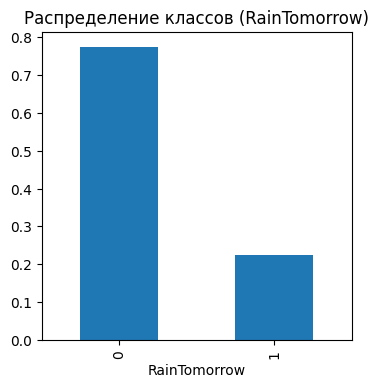

In [ ]:
# Доля классов
class_counts = y.value_counts(normalize=True)
print("Распределение классов:")
print(class_counts)

# Визуализация
plt.figure(figsize=(4,4))
class_counts.plot(kind='bar')
plt.title("Распределение классов (RainTomorrow)")
plt.show()

Если классы сильно несбалансированы, то модель может переобучиться на большой класс и плохо предсказывать малый. Здесь дисбаланс не критичный, и данные позволяют обучить LDA/QDA, но при анализе результатов нужно уделять особое внимание качеству на меньшем классе.

### Корреляция признаков

Из предыдущей работы знаем, что сильная корреляция обнаружена между признаками:
- Температур: MinTemp, MaxTemp, Temp9am, Temp3pm
- Давления: Pressure3pm, Pressure9am
- Облачности: Cloud3pm, Cloud9am


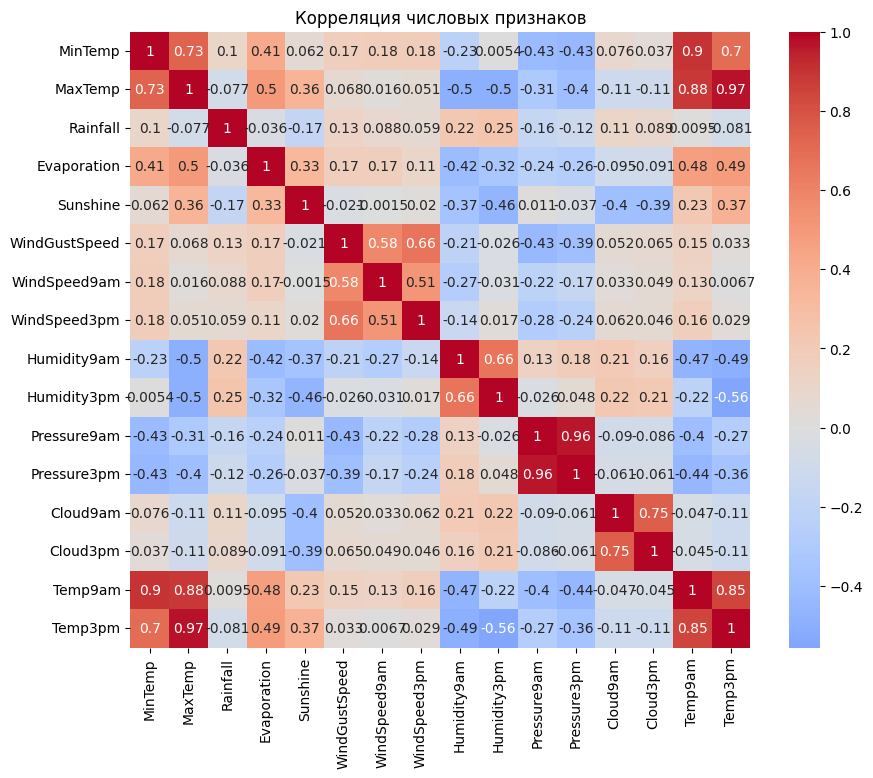

In [ ]:
# Только числовые признаки
numeric_features = X.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_features.corr(), cmap="coolwarm", center=0, annot=True)
plt.title("Корреляция числовых признаков")
plt.show()

Посмотрим корреляцию признаков с целевой переменной.

In [ ]:
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns
corr_with_target = X[numeric_features].apply(lambda x: x.corr(y))
corr_with_target.sort_values(ascending=False)

,0
Humidity3pm,0.438778
Humidity9am,0.254793
Rainfall,0.237478
WindGustSpeed,0.223927
Cloud3pm,0.174630
Cloud9am,0.155882
WindSpeed9am,0.091339
WindSpeed3pm,0.087951
MinTemp,0.083811
Temp9am,-0.025347


На основе анализа корреляции между числовыми признаками и их связи с целевой переменной можно удалить следующие:

- MinTemp, MaxTemp, Temp9am: сильно коррелируют между собой и с Temp3pm, а Temp3pm имеет наибольшую по модулю корреляцию с целевой переменной, поэтому оставляю только Temp3pm.
- Pressure3pm: высокая корреляция с Pressure9am, при этом Pressure9am имеет чуть более сильную связь с целевой переменной.
- Cloud9am: высокая корреляция с Cloud3pm, Cloud3pm имеет чуть более высокую корреляцию с целевой переменной, поэтому оставляю только его.

Для LDA/QDA лучше оставлять только те признаки, которые действительно дают информацию о целевой переменной, поэтому также удалю признаки WindSpeed9am, WindSpeed3pm, Evaporation со слабой корреляцией с целевой переменной.

In [ ]:
# Список признаков для удаления
features_to_drop = ['MinTemp', 'MaxTemp', 'Temp9am', 'Pressure3pm', 'Cloud9am', 'WindSpeed9am', 'WindSpeed3pm', 'Evaporation' ]

# Удаляем из X
X_reduced = X.drop(columns=features_to_drop)
# Удаляем из тестовой выборки
X_test_reduced = X_test.drop(columns=features_to_drop)




In [ ]:
X_reduced.head()

,Rainfall,Sunshine,WindGustSpeed,Humidity9am,Humidity3pm,Pressure9am,Cloud3pm,Temp3pm,RainToday,Location_Albany,...,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,Year,Month,Day
0,-0.279738,0.173575,-1.514386,-0.043681,-0.218721,-0.007464,-1.138593,0.236546,0,False,...,False,False,False,False,False,False,False,2014,5,24
1,-0.086900,-0.664637,0.084034,1.327416,1.240866,0.792987,-1.138593,-1.129131,1,False,...,False,False,False,False,False,False,False,2016,9,4
2,-0.279738,1.640447,-0.677118,-0.940167,-1.337739,-0.733800,-0.828984,2.561103,0,False,...,False,False,False,False,False,False,False,2011,1,26
3,0.515718,0.173575,0.084034,1.380150,0.948949,-0.941324,1.338278,-1.376115,1,False,...,False,False,False,False,False,False,False,2013,8,22
4,-0.279738,1.535670,1.073531,-0.623761,-0.753904,1.326621,-0.828984,0.817685,0,False,...,False,False,True,False,False,False,False,2011,10,19


In [ ]:
X_test_reduced.head()

,Rainfall,Sunshine,WindGustSpeed,Humidity9am,Humidity3pm,Pressure9am,Cloud3pm,Temp3pm,RainToday,Location_Albany,...,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,Year,Month,Day
106906,-0.279738,0.557756,1.758568,-1.414778,-1.678309,-0.037111,-1.138593,0.381831,0,False,...,False,False,False,False,False,False,True,2012,10,6
127803,0.178252,0.173575,-0.677118,1.432885,2.311231,-1.341550,-1.138593,-1.158188,1,False,...,False,True,False,False,False,False,False,2011,10,2
25835,-0.279738,0.173575,0.236264,0.272726,-2.164838,-0.007464,-1.138593,1.907321,0,False,...,False,False,False,False,False,False,False,2013,11,2
90081,4.444792,-0.315382,-0.372657,0.589133,0.559725,-0.644861,1.338278,1.268068,1,False,...,False,False,False,False,False,False,False,2017,1,18
5624,-0.255633,0.173575,-0.753234,1.643823,-0.316027,1.534146,-1.138593,0.541644,0,False,...,False,False,False,False,False,False,False,2016,4,27


Остались только информативные и относительно независимые признаки, которые будут использоваться для обучения моделей LDA и QDA.

## 2. Задача классификации

Используем алгоритмы LDA и QDA для классификации задачи "Предсказать дождь завтра".

LDA предполагает, что ковариационные матрицы классов одинаковые, поэтому строятся линейные границы раздела между классами. Это более устойчивый метод, особенно если выборка большая. QDA допускает разные ковариационные матрицы для классов, поэтому границы между ними могут быть более сложными, обычно лучше работает при большом количестве данных, но может переобучаться при малой выборке или сильном дисбалансе.

В датасете наблюдается значительный дисбаланс классов, поэтому LDA, как более устойчивый метод, вероятно даст лучшие результаты. QDA же из-за меньшего числа наблюдений для редкого класса может переобучаться и показывать худшую обобщающую способность.

Сравним качество работы LDA и QDA по метрике Accuracy и посмотрим, какой метод оказывается более уместным для данного набора данных.

In [ ]:
# Делим объединённую выборку обратно на тестовую и валидационную
X_train, X_val, y_train, y_val = train_test_split(
    X_reduced, y,
    test_size=0.2,  # 20% под валидацию
    random_state=42,
    stratify=y  # важно при дисбалансе классов, чтобы соотношение классов в train и val было примерно такое же, как в исходных данных
)

print("Train size:", X_train.shape, y_train.shape)
print("Val size:", X_val.shape, y_val.shape)
print("Test size:", X_test_reduced.shape, y_test.shape)

Train size: (96691, 60) (96691,)
Val size: (24173, 60) (24173,)
Test size: (21329, 60) (21329,)


Сохранение данных для последущих работ:

In [ ]:
import joblib
from google.colab import files

joblib.dump((X_train, y_train), "train_reduced.pkl")
joblib.dump((X_val, y_val), "val_reduced.pkl")
joblib.dump((X_test_reduced, y_test), "test_reduced.pkl")

files.download("train_reduced.pkl")
files.download("val_reduced.pkl")
files.download("test_reduced.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Linear Discriminant Analysis (LDA)


LDA results:
Validation Accuracy: 0.8397
Test Accuracy: 0.8435

Classification report (LDA):
              precision    recall  f1-score   support

           0       0.87      0.94      0.90     16548
           1       0.71      0.50      0.59      4781

    accuracy                           0.84     21329
   macro avg       0.79      0.72      0.75     21329
weighted avg       0.83      0.84      0.83     21329



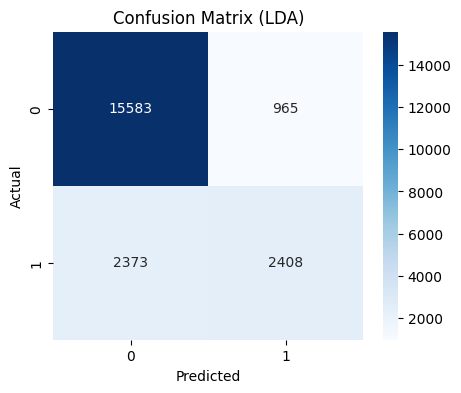

In [ ]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Валидация
y_val_pred_lda = lda.predict(X_val)
val_acc_lda = accuracy_score(y_val, y_val_pred_lda)

# Тест
y_test_pred_lda = lda.predict(X_test_reduced)
test_acc_lda = accuracy_score(y_test, y_test_pred_lda)

print("LDA results:")
print("Validation Accuracy:", round(val_acc_lda, 4))
print("Test Accuracy:", round(test_acc_lda, 4))
print("\nClassification report (LDA):")
print(classification_report(y_test, y_test_pred_lda))

# Матрица ошибок
cm_lda = confusion_matrix(y_test, y_test_pred_lda)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (LDA)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

На тестовой выборке модель достигла Accuracy 84.3%, что является достаточно высоким результатом.

Класс 0 (нет дождя): precision = 0.87, recall = 0.94, модель хорошо предсказывает отсутствие дождя, почти не пропуская такие случаи.  
Класс 1 (будет дождь): precision = 0.71, recall = 0.50, модель определяет дождь хуже, часто не улавливает реальные дождливые дни (низкий recall).   
F1-score для дождя = 0.59, модель игнорирует часть дождливых случаев из-за дисбаланса классов.  

В целом, LDA показывает хорошие результаты для данной задачи, но её предсказания стоит дополнять методами, более чувствительными к редким событиям.


### Quadratic Discriminant Analysis (QDA)


QDA results:
Validation Accuracy: 0.6475
Test Accuracy: 0.6525

Classification report (QDA):
              precision    recall  f1-score   support

           0       0.89      0.63      0.74     16548
           1       0.36      0.72      0.48      4781

    accuracy                           0.65     21329
   macro avg       0.62      0.68      0.61     21329
weighted avg       0.77      0.65      0.68     21329



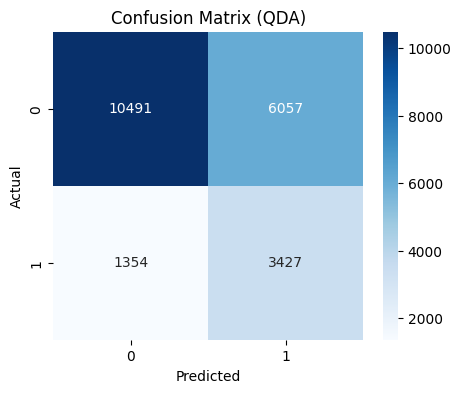

In [ ]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

# Валидация
y_val_pred_qda = qda.predict(X_val)
val_acc_qda = accuracy_score(y_val, y_val_pred_qda)

# Тест
y_test_pred_qda = qda.predict(X_test_reduced)
test_acc_qda = accuracy_score(y_test, y_test_pred_qda)

print("QDA results:")
print("Validation Accuracy:", round(val_acc_qda, 4))
print("Test Accuracy:", round(test_acc_qda, 4))
print("\nClassification report (QDA):")
print(classification_report(y_test, y_test_pred_qda))

# Матрица ошибок
cm_qda = confusion_matrix(y_test, y_test_pred_qda)
plt.figure(figsize=(5,4))
sns.heatmap(cm_qda, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (QDA)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

На тестовой выборке модель показала Accuracy 65.3%, что заметно ниже, чем у LDA.  
Класс 0 (нет дождя): precision = 0.89, recall = 0.63, модель часто пропускает случаи без дождя.  
Класс 1 (будет дождь): precision = 0.36, recall = 0.72, модель улавливает многие дождливые дни (высокий recall), но при этом часто ошибается (низкая точность).  
F1-score для дождя = 0.48, что сильно хуже, чем у LDA.  

QDA лучше справляется с выявлением случаев «дождь», однако точность модели в целом низкая. Это вероятно связано с тем, что квадратичные границы разделения переобучаются на сложных зависимостях данных и менее устойчивы.   


**Сравнение по метрикам**

LDA: Accuracy 0.84, Precision (класс 1) 0.71, Recall (класс 1) 0.50, F1 (класс 1) 0.59  
QDA: Accuracy 0.65, Precision (класс 1) 0.36, Recall (класс 1) 0.72, F1 (класс 1) 0.48

LDA показал лучший общий результат и по Accuracy, и по F1-score. QDA чаще ловит настоящие дождливые дни, но при этом модель часто предсказывает дождь там, где его нет. LDA наоборот предсказывает дождь реже, но когда предсказывает чаще права. Для данного датасета QDA оказывается менее уместным, чем LDA, так как его предсказания менее сбалансированы и качество хуже.

Можно посмотреть на графике баланс между recall и precision для положительного класса обеих моделей.

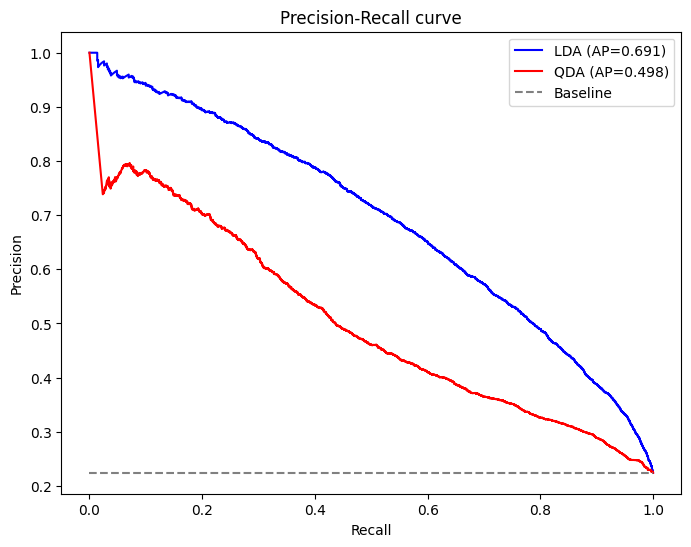

In [ ]:
# Вероятности принадлежности к классу "1"
y_scores_lda = lda.predict_proba(X_test_reduced)[:, 1]
y_scores_qda = qda.predict_proba(X_test_reduced)[:, 1]

# Precision-Recall для LDA
precision_lda, recall_lda, _ = precision_recall_curve(y_test, y_scores_lda)
ap_lda = average_precision_score(y_test, y_scores_lda)

# Precision-Recall для QDA
precision_qda, recall_qda, _ = precision_recall_curve(y_test, y_scores_qda)
ap_qda = average_precision_score(y_test, y_scores_qda)

# График
plt.figure(figsize=(8,6))
plt.plot(recall_lda, precision_lda, label=f"LDA (AP={ap_lda:.3f})", color="blue")
plt.plot(recall_qda, precision_qda, label=f"QDA (AP={ap_qda:.3f})", color="red")

# Базовая линия (доля положительного класса)
baseline = y_test.mean()
plt.hlines(baseline, 0, 1, colors='gray', linestyles='--', label='Baseline')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")
plt.legend()
plt.show()

На графике изображены кривые precision-recall для моделей LDA и QDA, а также базовая линия (baseline), которая соответствует случайному классификатору. Базовая линия показывает точность случайной модели, предсказывающей класс "дождь" с вероятностью, равной его доле в выборке (около 22%).  

LDA кривая значительно выше baseline и демонстрирует хороший компромисс между precision и recall. Это говорит о том, что модель уверенно выделяет дождливые дни и делает это лучше случайного угадывания. QDA кривая также выше baseline, но заметно ниже, чем у LDA. Это означает, что QDA хуже справляется с дисбалансом классов и в целом менее устойчива на этих данных.  

Таким образом, LDA показывает себя более надёжной и уместной моделью для данной задачи, в то время как QDA даёт менее устойчивые результаты и сильнее подвержена ошибкам.


## 3. Задача тематического моделирования

Для использования Probabilistic LSA (pLSA) нужны текстовые данные, так как pLSA предназначен для тематического моделирования: выявления скрытых тем в корпусе документов. В используемом датасете с погодными данными содержатся только числовые и категориальные признаки и нет текстовых документов, что делает применение pLSA некорректным.

Поэтому для этой части работы был выбран новый датасет, который содержит текстовые данные, чтобы корректно применить метод pLSA, оценить его качество (perplexity) и сделать выводы о скрытых темах в данных.

Датасет Road accidents in the Czech Republic: https://www.kaggle.com/datasets/pereprosov/road-accidents-in-the-czech-republic

Данные получены от полиции Чешской Республики о дорожно-транспортных происшествиях по всей стране. Будет использоваться файл pedestrian.csv: каждая строка в файле соответствует отдельному дорожно-транспортному происшествию с участием пешехода, при этом различные атрибуты, связанные с инцидентом, отображаются в виде столбцов.

Признаки датасета:  
'Unnamed: 0' - индекс строки, 'id' - идентификатор происшествия, 'pedestrian_category' - категория пешехода (например, мужчина, женщина, ребёнок), 'pedestrian_condition' - состояние пешехода на момент происшествия (например, трезвый, под воздействием алкоголя, невнимательный), 'pedestrian_behaviour' - поведение пешехода перед происшествием (например, переход по пешеходному переходу, внезапный выход на дорогу), 'situation_at_the_point_of_accident' - обстоятельства происшествия в месте столкновения (например, стандартная ситуация, особая ситуация на дороге).


In [ ]:
# Загрузка данных
url = 'https://raw.githubusercontent.com/GusevaVarvara/Weather-dataset/refs/heads/main/pedestrian.csv'
data = pd.read_csv(url)

In [ ]:
print("\nРазмер данных (строки, столбцы):", data.shape)
print("Названия столбцов:", data.columns.tolist())


Размер данных (строки, столбцы): (22945, 6)
Названия столбцов: ['Unnamed: 0', 'id', 'pedestrian_category', 'pedestrian_condition', 'pedestrian_behaviour', 'situation_at_the_point_of_accident']


In [ ]:
data.head()

,Unnamed: 0,id,pedestrian_category,pedestrian_condition,pedestrian_behaviour,situation_at_the_point_of_accident
0,0,2100180003,Woman,under the influence of alcohol with a blood al...,sudden entry into the roadway from the sidewal...,another situation
1,1,2100180007,Woman,good no adverse circumstances were found,"correct, appropriate",crossing at a marked crossing
2,2,2100180039,man,under the influence of alcohol with a blood al...,sudden entry into the roadway from the sidewal...,another situation
3,3,2100180047,man,"inattention, distraction",sudden entry into the roadway from the sidewal...,another situation
4,4,2100180051,Woman,good no adverse circumstances were found,"correct, appropriate",crossing at a marked crossing


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22945 entries, 0 to 22944
Data columns (total 6 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Unnamed: 0                          22945 non-null  int64 
 1   id                                  22945 non-null  int64 
 2   pedestrian_category                 22945 non-null  object
 3   pedestrian_condition                22945 non-null  object
 4   pedestrian_behaviour                19153 non-null  object
 5   situation_at_the_point_of_accident  22945 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.1+ MB


In [ ]:
# Удаляем строки с пропусками в текстовых признаках
data = data.dropna(subset=['pedestrian_category', 'pedestrian_condition', 'pedestrian_behaviour',
                       'situation_at_the_point_of_accident'])

# Удаляем дубликаты
data = data.drop_duplicates()

print("Размер после удаления пропусков и дубликатов:", data.shape)

Размер после удаления пропусков и дубликатов: (19153, 6)


Для pLSA нужны только текстовые данные, поэтому удаляем числовые признаки.

In [ ]:
data = data.drop(columns=['Unnamed: 0', 'id'])
data.head()


,pedestrian_category,pedestrian_condition,pedestrian_behaviour,situation_at_the_point_of_accident
0,Woman,under the influence of alcohol with a blood al...,sudden entry into the roadway from the sidewal...,another situation
1,Woman,good no adverse circumstances were found,"correct, appropriate",crossing at a marked crossing
2,man,under the influence of alcohol with a blood al...,sudden entry into the roadway from the sidewal...,another situation
3,man,"inattention, distraction",sudden entry into the roadway from the sidewal...,another situation
4,Woman,good no adverse circumstances were found,"correct, appropriate",crossing at a marked crossing


Есть несколько текстовых признаков: pedestrian_category, pedestrian_condition, pedestrian_behaviour, situation_at_the_point_of_accident. Их можно объединить в один текстовый столбец для тематического моделирования.

In [ ]:
# Все текстовые признаки в один столбец
data['text'] = data['pedestrian_category'].astype(str) + ' ' + \
             data['pedestrian_condition'].astype(str) + ' ' + \
             data['pedestrian_behaviour'].astype(str) + ' ' + \
             data['situation_at_the_point_of_accident'].astype(str)

# Оставляем только объединённый текстовый столбец
data_text = data[['text']]
data_text.head()

,text
0,Woman under the influence of alcohol with a bl...
1,Woman good no adverse circumstances were found...
2,man under the influence of alcohol with a bloo...
3,"man inattention, distraction sudden entry into..."
4,Woman good no adverse circumstances were found...


Для pLSA лучше убрать лишние символы, привести текст к нижнему регистру и разделить на слова.

In [ ]:
def clean_text(text):
    text = text.lower()  # нижний регистр
    text = re.sub(r'[^a-z0-9\s]', '', text)  # оставить только буквы и цифры
    text = re.sub(r'\s+', ' ', text).strip()  # убрать лишние пробелы
    return text

data_text['text'] = data_text['text'].apply(clean_text)
data_text.head()

/tmp/ipython-input-4287599422.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_text['text'] = data_text['text'].apply(clean_text)


,text
0,woman under the influence of alcohol with a bl...
1,woman good no adverse circumstances were found...
2,man under the influence of alcohol with a bloo...
3,man inattention distraction sudden entry into ...
4,woman good no adverse circumstances were found...


Также для pLSA нужно представить текст как матрицу "документ–термин". Каждая строка: один документ (объединённый текст про аварию). Каждый столбец: одно уникальное слово (термин) из всех документов. Значения в матрице: количество раз, которое слово встречается в документе. Эта матрица нужна для pLSA, потому что алгоритм работает с частотами слов в документах, чтобы выявить скрытые темы.

Параметры:
- max_df=0.9: слова, которые встречаются в более чем 90% документов, игнорируются(слишком частые слова вроде the, and, a не несут информации)
- min_df=5: слова, которые встречаются менее 5 раз, тоже игнорируются (слишком редкие)
- stop_words='english': удаляет стандартные английские служебные слова
- fit_transform: строит словарь всех слов (терминов) и сразу превращает текст в матрицу.

In [ ]:
vectorizer = CountVectorizer(max_df=0.9, min_df=5, stop_words='english')
X = vectorizer.fit_transform(data_text['text'])

print("Размер матрицы документов и терминов:", X.shape)

Размер матрицы документов и терминов: (19153, 77)


Сначала реализуем **LSA**, этот метод есть в встроенной библиотеке sklearn. Он преобразует коллекцию текстовых документов в мешок слов, строит низкоразмерное тематическое пространство, где каждая тема представляет комбинацию слов, позволяет визуализировать документы в новом пространстве и понять, какие слова формируют темы.

У sklearn для TruncatedSVD нет метода perplexity, потому что LSA не является вероятностной моделью. Можно посчитать похожую метрику вручную через inverse_transform: есть метод transform (проекция документа в скрытое пространство) и inverse_transform (восстановление матрицы из скрытого пространства). Perplexity считается так: берём восстановленную матрицу X_proj, сравниваем её с исходной X, считаем логарифм вероятностей и получаем меру, насколько хорошо k-мерное пространство сохраняет информацию. Это не настоящая вероятностная perplexity, но что-то подобное.

Также посмотрим топ-слова каждой темы и визуализируем распределение документов в первых двух темах.

Perplexity: 1.714037348969911
Тема 1: crossing, adverse, circumstances, good, correct, appropriate, marked, woman, man, 20
Тема 2: crossing, sudden, roadway, sidewalk, shoulder, 20, outside, metres, entry, inattention
Тема 3: crossing, marked, metres, outside, 20, poor, estimation, distance, speed, impact
Тема 4: alcohol, man, influence, content, blood, correct, appropriate, situation, walking, 099
Тема 5: 15, child, years, alcohol, marked, blood, content, influence, vehicle, appropriate


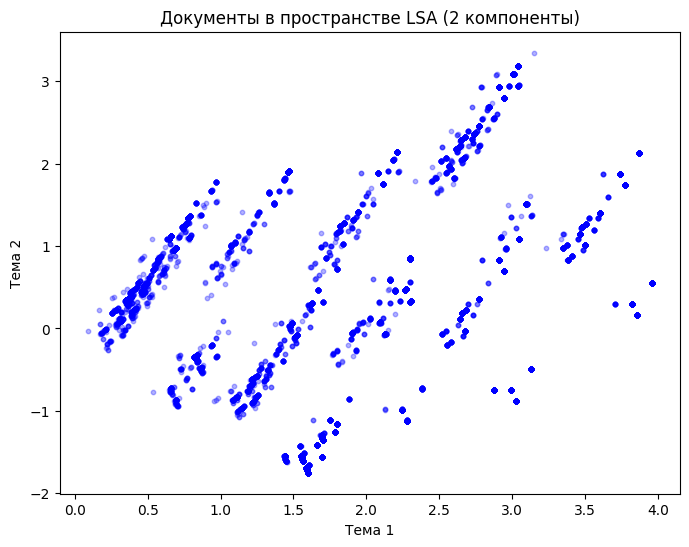

In [ ]:
# LSA
n_topics = 5
lsa = TruncatedSVD(n_components=n_topics, random_state=42)
X_lsa = lsa.fit_transform(X)

# Функция для подсчёта perplexity
def perplexity(X, model):
    X_proj = model.inverse_transform(model.transform(X))
    X_proj = np.maximum(X_proj, 1e-9)
    log_likelihood = (X.multiply(np.log(X_proj))).sum()
    n_words = X.sum()
    return np.exp(-log_likelihood / n_words)

perp = perplexity(X, lsa)
print("Perplexity:", perp)

# Топ-слов для каждой темы
terms = vectorizer.get_feature_names_out()
top_n = 10

for i, comp in enumerate(lsa.components_):
    top_terms = np.argsort(comp)[::-1][:top_n]
    print(f"Тема {i+1}: " + ", ".join(terms[top_terms]))

# Визуализация документов в первых двух темах
plt.figure(figsize=(8,6))
plt.scatter(X_lsa[:,0], X_lsa[:,1], alpha=0.3, s=10, c='blue')
plt.title("Документы в пространстве LSA (2 компоненты)")
plt.xlabel("Тема 1")
plt.ylabel("Тема 2")
plt.show()

**Perplexity = 1.714** показывает, что LSA хорошо сжала информацию в 5 тем. Чем меньше значение, тем компактнее представление документов в тематическом пространстве. Такое низкое значение может быть связано с не очень большим словарем (77 слов после фильтрации), модель быстро подогналась. По выведенным темам видно, что модель действительно разделила коллекцию документов на осмысленные скрытые темы, связанные с разными типами ДТП с пешеходами. Визуализация документов показала, что точки в первых двух темах распределились по нескольким группам, что отражает различие между типами происшествий.  

LSA успешно выявила основные темы в текстах, сохранив структуру документа в новом пространстве. Perplexity подтверждает эффективность модели.


Встроенного **pLSA** в sklearn нет, поэтому реализуем алгоритм EM по формулам из лекции, чтобы посмотреть на работу этого метода. Модель находит вероятность слова в теме и вероятность темы в документе через максимизацию логарифма правдоподобия.

Для pLSA сложнее посчитать Perplexity, встроенной функции нет, будем также считать по формуле. В отличие от LSA, где оцениваем качество восстановления матрицы признаков, в pLSA perplexity считается на основе вероятностной модели.

После работы EM-алгоритма есть две матрицы: вероятность слова w в теме t и вероятность темы t в документе d. Чтобы оценить качество модели, хотим посчитать, насколько хорошо она объясняет тексты. Берётся вероятность встретить слово в документе через комбинацию этих двух матриц, складываем логарифмы этих вероятностей по всем словам во всех документах. Это даёт логарифмическое правдоподобие (насколько хорошо модель предсказывает данные). Perplexity строится на основе этого числа: берём среднее по количеству слов и переводим обратно из логарифмов в нормальные значения.


In [ ]:
X = X.toarray()  # переход к numpy array массиву
vocab = np.array(vectorizer.get_feature_names_out()) # массив из слов словаря
D, W = X.shape  # количество документов и слов

# Параметры модели
T = 5       # число тем
imax = 30   # число итераций EM-алгоритма

# Инициализация φ и θ случайно
phi = np.random.rand(W, T) # вероятность слова w в теме t
phi = phi / phi.sum(axis=0, keepdims=True)  # нормировка по столбцам (для каждой темы t сумма по словам w равна 1)

theta = np.random.rand(T, D) # вероятность темы t в документе d
theta = theta / theta.sum(axis=0, keepdims=True)  # нормировка по столбцам (для каждого документа d суммы по темам t равны 1)

# EM-алгоритм
for iteration in range(imax):
    # E-шаг (формула Байеса)
    p_t_dw = np.zeros((T, D, W))  # p(t|d, w)
    for d in range(D):
        for w in range(W):
            if X[d, w] > 0: # число раз, которое слово w встречается в d
                # : нужно, чтобы взять все темы за один раз, без дополнительного цикла по t
                denom = np.sum(phi[w, :] * theta[:, d]) # знаменатель по формуле Байеса
                if denom == 0:
                    continue
                p_t_dw[:, d, w] = (phi[w, :] * theta[:, d]) / denom # формула Байеса

    # M-шаг, частотные оценки условных вероятностей
    n_wt = np.zeros((W, T)) # оценка ожидаемого числа раз, когда слово w относится к теме t
    n_td = np.zeros((T, D)) # оценка ожидаемого числа раз, когда тема t встречается в документе d
    n_t = np.zeros(T) # общее ожидаемое число вхождений темы t по всем документам и словам

    for t in range(T):
        for d in range(D):
            for w in range(W):
                count = X[d, w] * p_t_dw[t, d, w]
                n_wt[w, t] += count
                n_td[t, d] += count
                n_t[t] += count

    # Обновление φ и θ по формулам
    phi = n_wt / n_t[np.newaxis, :]
    theta = n_td / n_td.sum(axis=0, keepdims=True)

    # Вывод прогресса для контроля
    if (iteration + 1) % 5 == 0:
        print(f"Iteration {iteration+1} done")

# Вывод топ-слов по каждой теме
top_n = 10
for t in range(T):
    top_words = vocab[np.argsort(phi[:, t])[::-1][:top_n]]
    print(f"Topic {t+1}: {', '.join(top_words)}")

# Подсчет perplexity
N = X.sum()
log = 0.0

for d in range(D):
    for w in range(W):
        if X[d, w] > 0:
            prob = np.dot(phi[w, :], theta[:, d])
            if prob > 0:
                log += X[d, w] * np.log(prob)

perplexity = np.exp(-log / N)
print(f"Perplexity: {perplexity}")

Iteration 5 done
Iteration 10 done
Iteration 15 done
Iteration 20 done
Iteration 25 done
Iteration 30 done
Topic 1: adverse, good, circumstances, appropriate, correct, man, woman, situation, walking, right
Topic 2: entry, roadway, sudden, sidewalk, shoulder, pedestrian, inattention, distraction, signal, man
Topic 3: alcohol, man, influence, content, blood, vehicle, poor, estimation, speed, distance
Topic 4: crossing, marked, woman, circumstances, good, adverse, correct, appropriate, detected, man
Topic 5: crossing, 20, metres, outside, 15, years, child, adverse, good, circumstances
Perplexity: 17.806321563037624


Модель также разделила документы на пять тем, результаты похожи на LSA. pLSA показывает, как EM-алгоритм выделяет скрытые темы, используя вероятностную модель.

Perplexity получилось значительно больше, 17.8, что говорит о том, что модель хуже описывает тексты. Это объясняется как ограниченным числом итераций, так и тем, что алгоритм реализован без оптимизаций, регуляризации и тп.

## Вывод

В работе исследовано применение методов классификации (LDA, QDA) и тематического моделирования (Probabilistic LSA / LSA) на выбранных датасетах: для классификации был использован датасет погоды с целевой переменной RainTomorrow, для тематического моделирования был выбран новый датасет дорожно-транспортных происшествий с текстовыми признаками, оба набора данных обработаны для использования моделей.

Из полученных результатов можно сделать вывод, что для данного датасета LDA более уместна, так как классы можно аппроксимировать линейными границами, а QDA страдает от переобучения и меньшей точности на редком классе.

LSA позволила выявить основные темы текстов, perplexity показало значение 1.714, что говорит о том, что тематическое пространство хорошо отражает структуру данных. pLSA реализованно вручную по формулам из лекции, топ-слова тем схожи с LSA, что подтверждает правильность реализации EM-алгоритма. LSA показал себя лучше по метрике perplexity, т.е. сохраняет больше информации в тематическом пространстве. Темы у LSA получились более чёткими и раздельными, а у pLSA больше повторяющихся слов и менее чёткие границы. pLSA требует большего числа итераций, тонкой настройки и более аккуратной реализации для получения стабильного результата. В целом, тематическое моделирование успешно выделяет скрытые темы в текстах и демонстрирует внутреннюю структуру документов. LSA удобна для визуализации и быстрого анализа, pLSA показывает более формальный вероятностный подход.